# Machine Learning for Electron-Collision Events

**Author:** M.M.M.D. Ariyarathna

This notebook investigates machine-learning regression methods for predicting the invariant mass of two-electron collision events using a publicly available CERN/CMS Open Data sample.

### Methods
- Random Forest Regression
- Deep Neural Network (DNN)
- Principal Component Analysis (PCA)

The workflow includes data preprocessing, exploratory data analysis, model training, hyperparameter tuning, and evaluation using MAE, MSE, RMSE, and $R^2$.

## 1. Imports and configuration

The original project was developed in Google Colab. This cleaned version removes the Colab-specific file-upload dependency so that the notebook can be run locally or from a GitHub repository.

Place the downloaded CERN dataset at `data/dielectron.csv` before running the notebook.

In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Input

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")

DATA_PATH = Path("data/dielectron.csv")

if DATA_PATH.exists():
    print(f"Using dataset: {DATA_PATH}")
else:
    try:
        from google.colab import files

        print("Dataset not found.")
        print("Please upload dielectron.csv.")
        uploaded = files.upload()

        if "dielectron.csv" not in uploaded:
            raise FileNotFoundError(
                "Please upload the file named 'dielectron.csv'."
            )

        DATA_PATH = Path("dielectron.csv")

    except ImportError:
        raise FileNotFoundError(
            "Dataset not found. Please place dielectron.csv "
            "inside the data/ directory."
        )

df = pd.read_csv(DATA_PATH)

Dataset not found.
Please upload dielectron.csv.


Saving dielectron.csv to dielectron.csv


## 2. Load the dataset

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (100000, 19)


,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
0,147115,366639895,58.71410,-7.31132,10.531000,-57.29740,12.82020,-2.20267,2.17766,1,11.2836,-1.032340,-1.88066,-11.0778,2.14537,-2.344030,-2.072810,-1,8.94841
1,147115,366704169,6.61188,-4.15213,-0.579855,-5.11278,4.19242,-1.02842,-3.00284,-1,17.1492,-11.713500,5.04474,11.4647,12.75360,0.808077,2.734920,1,15.89300
2,147115,367112316,25.54190,-11.48090,2.041680,22.72460,11.66100,1.42048,2.96560,1,15.8203,-1.472800,2.25895,-15.5888,2.69667,-2.455080,2.148570,1,38.38770
3,147115,366952149,65.39590,7.51214,11.887100,63.86620,14.06190,2.21838,1.00721,1,25.1273,4.087860,2.59641,24.6563,4.84272,2.330210,0.565865,-1,3.72862
4,147115,366523212,61.45040,2.95284,-14.622700,-59.61210,14.91790,-2.09375,-1.37154,-1,13.8871,-0.277757,-2.42560,-13.6708,2.44145,-2.423700,-1.684810,-1,2.74718


## 3. Preprocessing

The original analysis used the following preprocessing steps:

1. Remove `Run` and `Event`.
2. Remove rows containing missing values.
3. Remove duplicate rows.
4. Inspect the 1st–99th percentile range for potential outliers.
5. Create composite features:
   - `pt_magnitude1`
   - `pt_magnitude2`
   - `abs_eta_diff`
   - `energy_diff`
6. Remove features with very weak correlation with the target variable $M$.

In [3]:
df.columns = df.columns.str.strip()

print("Original shape:", df.shape)

df = df.drop(columns=["Run", "Event"], errors="ignore")

missing_before = df.isna().sum().sum()
df = df.dropna().copy()
print(f"Missing values removed: {missing_before}")
print("Shape after removing missing values:", df.shape)

duplicates = df.duplicated().sum()
df = df.drop_duplicates().copy()
print(f"Duplicate rows removed: {duplicates}")
print("Shape after removing duplicates:", df.shape)

Original shape: (100000, 19)
Missing values removed: 85
Shape after removing missing values: (99915, 17)
Duplicate rows removed: 23
Shape after removing duplicates: (99892, 17)


In [4]:
numeric_df = df.select_dtypes(include=np.number)

lower_bound = numeric_df.quantile(0.01)
upper_bound = numeric_df.quantile(0.99)
outlier_counts = ((numeric_df < lower_bound) | (numeric_df > upper_bound)).sum()

print("Counts outside the 1st–99th percentile range:")
display(outlier_counts[outlier_counts > 0].sort_values(ascending=False))

Counts outside the 1st–99th percentile range:


,0
E1,1998
px1,1998
py1,1998
pz1,1998
pt1,1998
eta1,1998
phi1,1998
E2,1998
px2,1998
py2,1998


In [5]:
df["pt_magnitude1"] = np.hypot(df["px1"], df["py1"])
df["pt_magnitude2"] = np.hypot(df["px2"], df["py2"])
df["abs_eta_diff"] = (df["eta1"] - df["eta2"]).abs()
df["energy_diff"] = (df["E1"] - df["E2"]).abs()

print("Shape after feature engineering:", df.shape)
display(df.head())

Shape after feature engineering: (99892, 21)


,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,...,pz2,pt2,eta2,phi2,Q2,M,pt_magnitude1,pt_magnitude2,abs_eta_diff,energy_diff
0,58.71410,-7.31132,10.531000,-57.29740,12.82020,-2.20267,2.17766,1,11.2836,-1.032340,...,-11.0778,2.14537,-2.344030,-2.072810,-1,8.94841,12.820193,2.145369,0.141360,47.43050
1,6.61188,-4.15213,-0.579855,-5.11278,4.19242,-1.02842,-3.00284,-1,17.1492,-11.713500,...,11.4647,12.75360,0.808077,2.734920,1,15.89300,4.192424,12.753646,1.836497,10.53732
2,25.54190,-11.48090,2.041680,22.72460,11.66100,1.42048,2.96560,1,15.8203,-1.472800,...,-15.5888,2.69667,-2.455080,2.148570,1,38.38770,11.661026,2.696664,3.875560,9.72160
3,65.39590,7.51214,11.887100,63.86620,14.06190,2.21838,1.00721,1,25.1273,4.087860,...,24.6563,4.84272,2.330210,0.565865,-1,3.72862,14.061842,4.842721,0.111830,40.26860
4,61.45040,2.95284,-14.622700,-59.61210,14.91790,-2.09375,-1.37154,-1,13.8871,-0.277757,...,-13.6708,2.44145,-2.423700,-1.684810,-1,2.74718,14.917862,2.441451,0.329950,47.56330


### Correlation analysis

Correlation with target M:


,M
M,1.000000
abs_eta_diff,0.530582
pt1,0.437208
pt_magnitude1,0.437208
pt_magnitude2,0.437192
pt2,0.437192
E2,0.324691
E1,0.285270
energy_diff,0.175724
eta2,0.018756


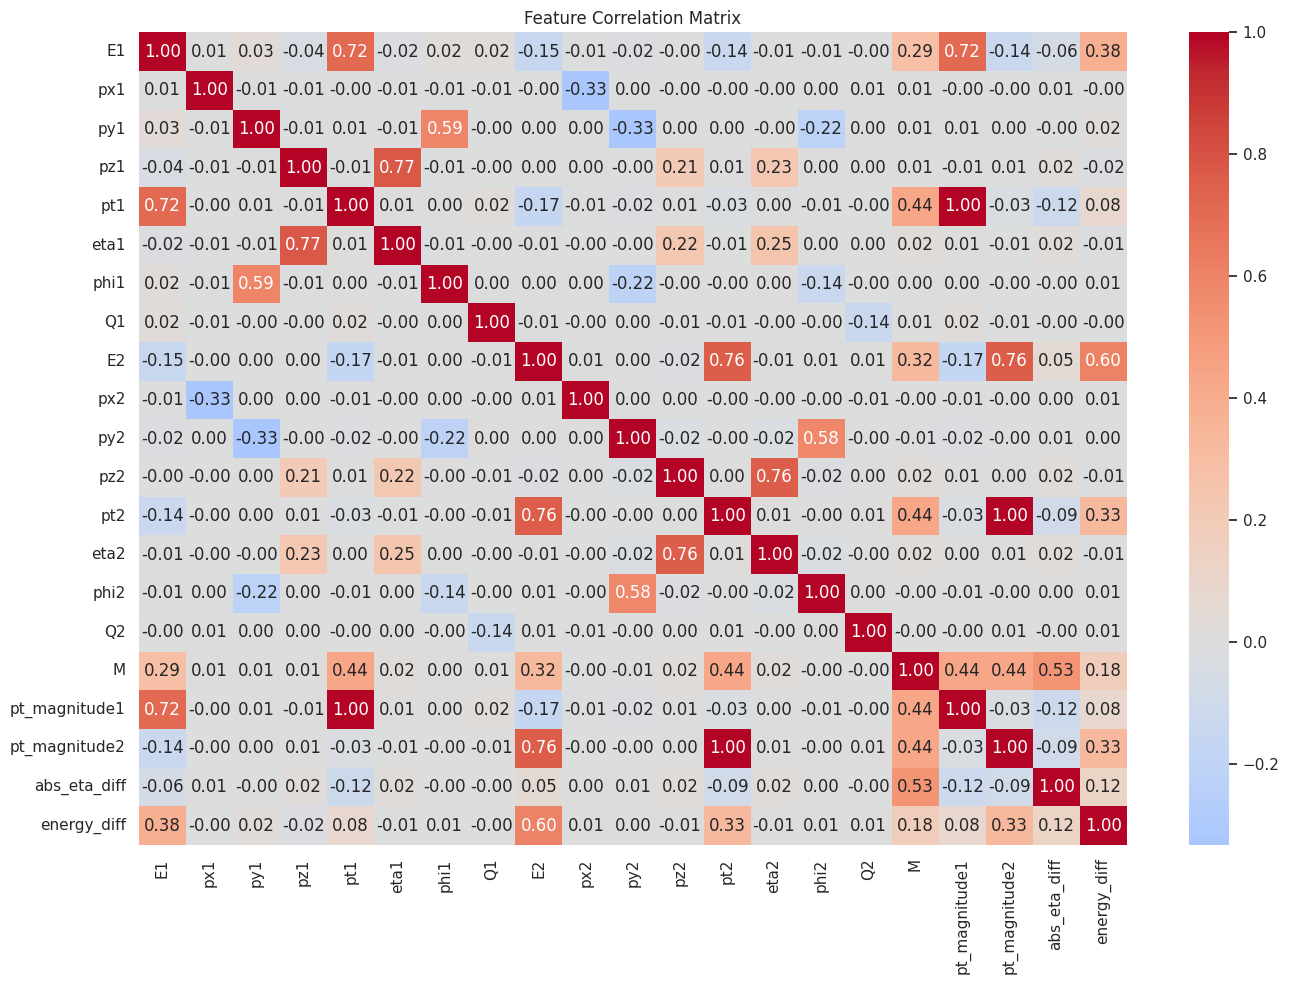

In [6]:
target = "M"

corr_matrix = df.corr(numeric_only=True)
target_corr = corr_matrix[target].sort_values(ascending=False)

print("Correlation with target M:")
display(target_corr)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [7]:
LOW_CORRELATION_FEATURES = [
    "py1", "px1", "Q1", "phi1",
    "Q2", "phi2", "px2", "py2"
]

df = df.drop(columns=LOW_CORRELATION_FEATURES)

print("Final pre-modeling shape:", df.shape)
print("Remaining features:")
print(df.columns.tolist())

Final pre-modeling shape: (99892, 13)
Remaining features:
['E1', 'pz1', 'pt1', 'eta1', 'E2', 'pz2', 'pt2', 'eta2', 'M', 'pt_magnitude1', 'pt_magnitude2', 'abs_eta_diff', 'energy_diff']


## 4. Exploratory Data Analysis

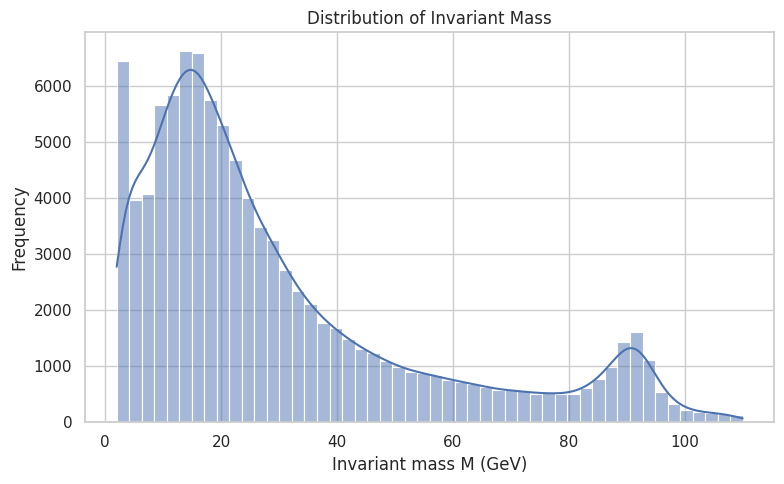

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df[target], bins=50, kde=True)
plt.title("Distribution of Invariant Mass")
plt.xlabel("Invariant mass M (GeV)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

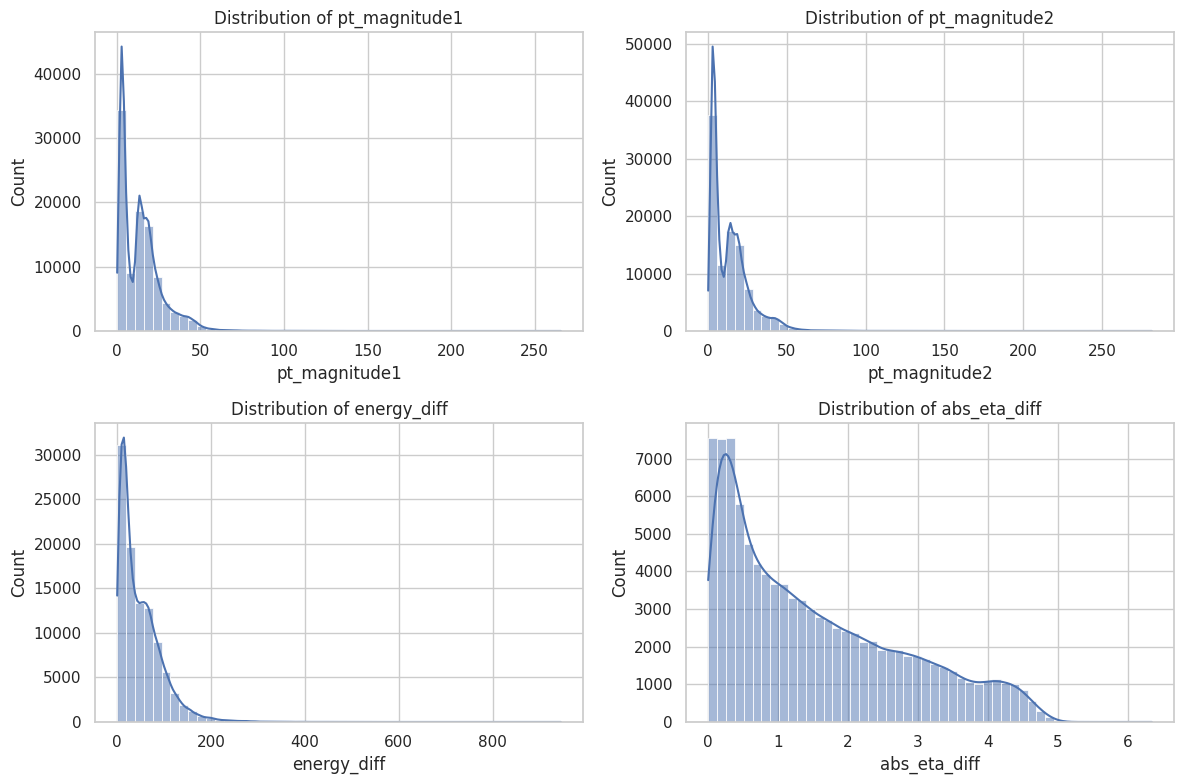

In [9]:
selected_features = [
    "pt_magnitude1",
    "pt_magnitude2",
    "energy_diff",
    "abs_eta_diff",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flat, selected_features):
    sns.histplot(df[feature], bins=50, kde=True, ax=ax)
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)

plt.tight_layout()
plt.show()

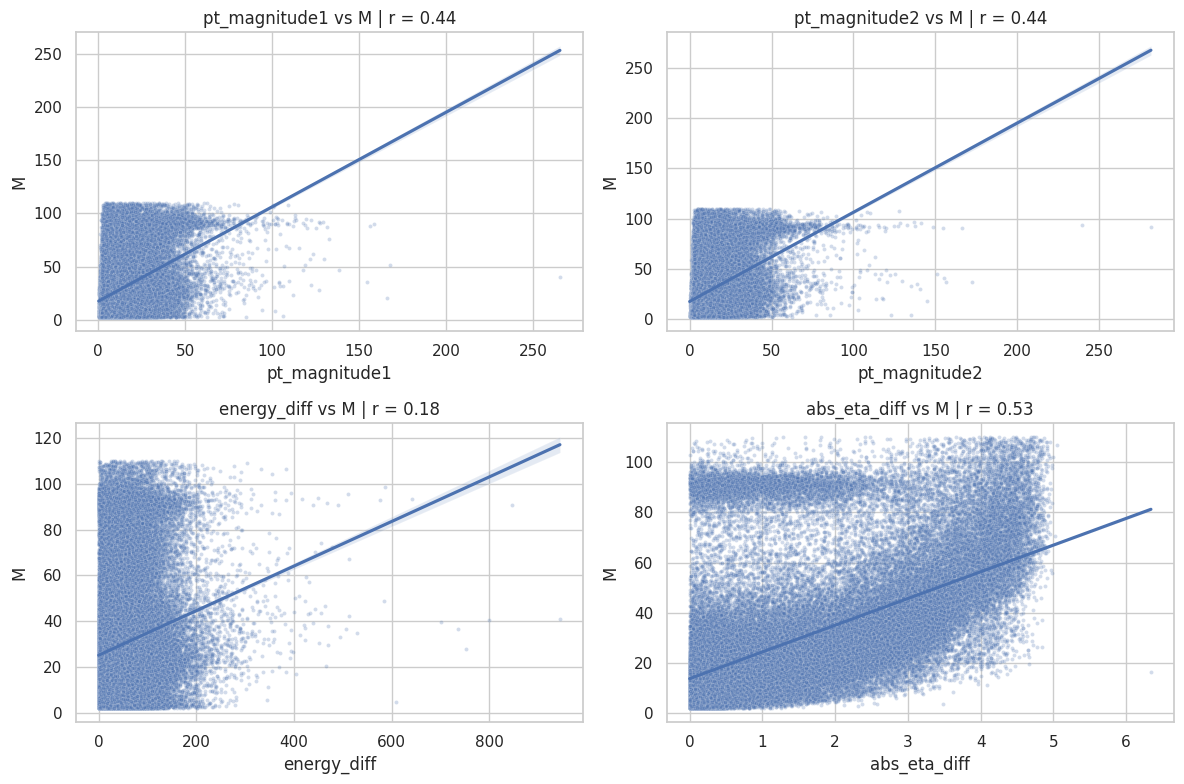

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flat, selected_features):
    sns.scatterplot(
        data=df,
        x=feature,
        y=target,
        s=8,
        alpha=0.25,
        ax=ax,
    )
    sns.regplot(
        data=df,
        x=feature,
        y=target,
        scatter=False,
        ax=ax,
    )

    correlation = df[[feature, target]].corr().iloc[0, 1]
    ax.set_title(f"{feature} vs {target} | r = {correlation:.2f}")

plt.tight_layout()
plt.show()

## 5. Train/test split and training subsets

The dataset is split into 80% training and 20% test data. The training data are then divided into five randomly shuffled subsets so that five independent model trainings can be compared using the same test set.

In [11]:
X = df.drop(columns=[target])
y = df[target]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    shuffle=True,
)

NUM_SUBSETS = 5

subset_indices = np.array_split(
    np.random.default_rng(RANDOM_STATE).permutation(len(X_train_full)),
    NUM_SUBSETS,
)

X_subsets = [X_train_full.iloc[idx].copy() for idx in subset_indices]
y_subsets = [y_train_full.iloc[idx].copy() for idx in subset_indices]

print(f"Full training set: {X_train_full.shape}")
print(f"Test set:          {X_test.shape}")

for i, (X_sub, y_sub) in enumerate(zip(X_subsets, y_subsets), start=1):
    print(f"Subset {i}: X={X_sub.shape}, y={y_sub.shape}")

Full training set: (79913, 12)
Test set:          (19979, 12)
Subset 1: X=(15983, 12), y=(15983,)
Subset 2: X=(15983, 12), y=(15983,)
Subset 3: X=(15983, 12), y=(15983,)
Subset 4: X=(15982, 12), y=(15982,)
Subset 5: X=(15982, 12), y=(15982,)


## 6. Evaluation utilities

In [12]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred),
    }


def print_metrics(metrics, label):
    print(label)
    print(f"  MAE  : {metrics['MAE']:.3f}")
    print(f"  MSE  : {metrics['MSE']:.3f}")
    print(f"  RMSE : {metrics['RMSE']:.3f}")
    print(f"  R²   : {metrics['R2']:.3f}")

# 7. Random Forest Regression — Original Feature Space

A Random Forest regressor is optimized using three-fold cross-validation. The hyperparameter search follows the parameter ranges used in the original project.

In [13]:
RF_PARAM_GRID = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15],
    "min_samples_split": [10, 15],
    "min_samples_leaf": [5, 10],
}


def train_random_forest(X_train, y_train):
    model = RandomForestRegressor(random_state=RANDOM_STATE)

    search = GridSearchCV(
        estimator=model,
        param_grid=RF_PARAM_GRID,
        cv=3,
        n_jobs=-1,
        scoring="r2",
        verbose=1,
    )

    search.fit(X_train, y_train)
    return search.best_estimator_, search.best_params_

In [ ]:
rf_results = []

for i, (X_sub, y_sub) in enumerate(zip(X_subsets, y_subsets), start=1):
    print(f"\n{'=' * 60}")
    print(f"Random Forest — Subset {i}")
    print(f"{'=' * 60}")

    model, best_params = train_random_forest(X_sub, y_sub)

    train_pred = model.predict(X_sub)
    test_pred = model.predict(X_test)

    train_metrics = regression_metrics(y_sub, train_pred)
    test_metrics = regression_metrics(y_test, test_pred)

    print("Best hyperparameters:", best_params)
    print_metrics(train_metrics, "Training performance:")
    print_metrics(test_metrics, "Test performance:")

    rf_results.append({
        "Model": i,
        **{f"Train_{k}": v for k, v in train_metrics.items()},
        **{f"Test_{k}": v for k, v in test_metrics.items()},
    })

rf_results_df = pd.DataFrame(rf_results)
display(rf_results_df.round(3))


Random Forest — Subset 1
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best hyperparameters: {'max_depth': 15, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}
Training performance:
  MAE  : 2.471
  MSE  : 13.012
  RMSE : 3.607
  R²   : 0.980
Test performance:
  MAE  : 3.549
  MSE  : 26.651
  RMSE : 5.162
  R²   : 0.958

Random Forest — Subset 2
Fitting 3 folds for each of 16 candidates, totalling 48 fits


# 8. Deep Neural Network — Original Feature Space

For each training subset, the input features are standardized before DNN training. The scaler used for a given subset is also used to transform the common test set.

The network architecture follows the original project: **64 → 64 → 32 → 1**, with ReLU activations in the hidden layers and a linear output for regression.

In [ ]:
def build_dnn(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation="relu"),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(1, activation="linear"),
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"],
    )

    return model

In [ ]:
dnn_results = []
dnn_histories = []

for i, (X_sub, y_sub) in enumerate(zip(X_subsets, y_subsets), start=1):
    print(f"\n{'=' * 60}")
    print(f"DNN — Subset {i}")
    print(f"{'=' * 60}")

    scaler = StandardScaler()
    X_sub_scaled = scaler.fit_transform(X_sub)
    X_test_scaled = scaler.transform(X_test)

    model = build_dnn(X_sub_scaled.shape[1])

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
    )

    history = model.fit(
        X_sub_scaled,
        y_sub,
        validation_split=0.20,
        epochs=200,
        batch_size=64,
        callbacks=[early_stop],
        verbose=1,
    )

    train_pred = model.predict(X_sub_scaled, verbose=0).ravel()
    test_pred = model.predict(X_test_scaled, verbose=0).ravel()

    train_metrics = regression_metrics(y_sub, train_pred)
    test_metrics = regression_metrics(y_test, test_pred)

    print_metrics(train_metrics, "Training performance:")
    print_metrics(test_metrics, "Test performance:")

    dnn_results.append({
        "Model": i,
        **{f"Train_{k}": v for k, v in train_metrics.items()},
        **{f"Test_{k}": v for k, v in test_metrics.items()},
    })
    dnn_histories.append(history)

dnn_results_df = pd.DataFrame(dnn_results)
display(dnn_results_df.round(3))

## 9. DNN training curves

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, history in enumerate(dnn_histories, start=1):
    ax = axes.flat[i - 1]
    ax.plot(history.history["loss"], label="Train loss")
    ax.plot(history.history["val_loss"], label="Validation loss")
    ax.set_title(f"DNN Subset {i}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE")
    ax.legend()

plt.tight_layout()
plt.show()

# 10. Principal Component Analysis

PCA is applied after standardization, retaining 95% of the variance. The PCA transformation is fitted on the complete training set and then applied to the common test set.

In [ ]:
pca_scaler = StandardScaler()

X_train_scaled = pca_scaler.fit_transform(X_train_full)
X_test_scaled = pca_scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=RANDOM_STATE)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original number of features: {X_train_full.shape[1]}")
print(f"Number of PCA components:   {X_train_pca.shape[1]}")
print(f"Explained variance retained: {pca.explained_variance_ratio_.sum():.3f}")

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(
    np.arange(1, len(pca.explained_variance_ratio_) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    marker="o",
)
plt.axhline(0.95, linestyle="--", label="95% variance")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
pca_indices = np.array_split(
    np.random.default_rng(RANDOM_STATE).permutation(len(X_train_pca)),
    NUM_SUBSETS,
)

X_pca_subsets = [X_train_pca[idx] for idx in pca_indices]
y_pca_subsets = [y_train_full.iloc[idx].copy() for idx in pca_indices]

for i, (X_sub, y_sub) in enumerate(zip(X_pca_subsets, y_pca_subsets), start=1):
    print(f"Subset {i}: X={X_sub.shape}, y={y_sub.shape}")

print(f"Test set: X={X_test_pca.shape}, y={y_test.shape}")

# 11. Random Forest Regression — PCA Feature Space

In [ ]:
rf_pca_results = []

for i, (X_sub, y_sub) in enumerate(zip(X_pca_subsets, y_pca_subsets), start=1):
    print(f"\n{'=' * 60}")
    print(f"Random Forest + PCA — Subset {i}")
    print(f"{'=' * 60}")

    model, best_params = train_random_forest(X_sub, y_sub)

    train_pred = model.predict(X_sub)
    test_pred = model.predict(X_test_pca)

    train_metrics = regression_metrics(y_sub, train_pred)
    test_metrics = regression_metrics(y_test, test_pred)

    print("Best hyperparameters:", best_params)
    print_metrics(train_metrics, "Training performance:")
    print_metrics(test_metrics, "Test performance:")

    rf_pca_results.append({
        "Model": i,
        **{f"Train_{k}": v for k, v in train_metrics.items()},
        **{f"Test_{k}": v for k, v in test_metrics.items()},
    })

rf_pca_results_df = pd.DataFrame(rf_pca_results)
display(rf_pca_results_df.round(3))

# 12. Deep Neural Network — PCA Feature Space

In [ ]:
dnn_pca_results = []
dnn_pca_histories = []

for i, (X_sub, y_sub) in enumerate(zip(X_pca_subsets, y_pca_subsets), start=1):
    print(f"\n{'=' * 60}")
    print(f"DNN + PCA — Subset {i}")
    print(f"{'=' * 60}")

    model = build_dnn(X_sub.shape[1])

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
    )

    history = model.fit(
        X_sub,
        y_sub,
        validation_split=0.20,
        epochs=200,
        batch_size=64,
        callbacks=[early_stop],
        verbose=1,
    )

    train_pred = model.predict(X_sub, verbose=0).ravel()
    test_pred = model.predict(X_test_pca, verbose=0).ravel()

    train_metrics = regression_metrics(y_sub, train_pred)
    test_metrics = regression_metrics(y_test, test_pred)

    print_metrics(train_metrics, "Training performance:")
    print_metrics(test_metrics, "Test performance:")

    dnn_pca_results.append({
        "Model": i,
        **{f"Train_{k}": v for k, v in train_metrics.items()},
        **{f"Test_{k}": v for k, v in test_metrics.items()},
    })
    dnn_pca_histories.append(history)

dnn_pca_results_df = pd.DataFrame(dnn_pca_results)
display(dnn_pca_results_df.round(3))

## 13. DNN training curves after PCA

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, history in enumerate(dnn_pca_histories, start=1):
    ax = axes.flat[i - 1]
    ax.plot(history.history["loss"], label="Train loss")
    ax.plot(history.history["val_loss"], label="Validation loss")
    ax.set_title(f"DNN + PCA Subset {i}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE")
    ax.legend()

plt.tight_layout()
plt.show()

# 14. Model comparison

The following table summarizes the test-set $R^2$ scores across the five training subsets.

In [ ]:
comparison = pd.DataFrame({
    "RF": rf_results_df["Test_R2"],
    "DNN": dnn_results_df["Test_R2"],
    "RF + PCA": rf_pca_results_df["Test_R2"],
    "DNN + PCA": dnn_pca_results_df["Test_R2"],
})

display(comparison.round(3))

print("Mean test R²:")
display(comparison.mean().sort_values(ascending=False).round(3))

## 15. Reproducibility notes

- The dataset is **not included** in this repository. Download it from the CERN/CMS Open Data Portal and place it at `data/dielectron.csv`.
- Random seeds are fixed where practical to make the train/test split and subset construction reproducible.
- TensorFlow/DNN results can still vary slightly across hardware and software environments.